In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
from process_data import extract_data, n_extract_data
pv.start_xvfb()
pv.set_jupyter_backend('static')
from scipy.spatial.transform import Rotation
import sys
sys.path.append("/local/scratch/groves/jax-forgeRL/models/forging_autoencoder/model")
from utils import *


In [ ]:
total_points = 512
lines = 100_000
db_path1 = '/local/scratch/groves/jax-forgeRL/jax-forge/data/tianhong_data/noisy_cogging.db'
db_path2 = '/local/scratch/groves/jax-forgeRL/jax-forge/data/tianhong_data/RL_random_cogging.db'
c_t1, c_tp11, s1, p1, r1, series_lengths1, series_ids1 = n_extract_data(db_path1, total_points, lines, n_workers=64)
c_t2, c_tp12, s2, p2, r2, series_lengths2, series_ids2 = n_extract_data(db_path2, total_points, lines, n_workers=64)


Processing 10 series using 8 workers...


Processing series: 100%|██████████| 10/10 [00:08<00:00,  1.16it/s]

Processing 4 series using 8 workers...



Processing series: 100%|██████████| 4/4 [00:09<00:00,  2.44s/it]


In [3]:
c_t = np.vstack((c_t1, c_t2))
c_tp1 = np.vstack((c_tp11, c_tp12))
s = np.vstack((s1, s2))
p = np.vstack((p1, p2))
r = np.vstack((r1,r2))
series_lengths = series_lengths1 + series_lengths2
series_ids = series_ids1 + series_ids2

# group_df = extract_data(db_path, total_points, lines)

# group_df.head()

In [4]:
print(c_t.shape), print(c_tp1.shape), print(s.shape), print(p.shape), print(r.shape)
print(series_lengths)
print(series_ids)

(986, 2048, 3)
(986, 2048, 3)
(986, 1)
(986, 3)
(986, 4)
[11, 53, 10, 51, 83, 79, 137, 7, 49, 10, 149, 149, 149, 49]
['3abff69b-8adf-4ce8-8492-b07325c47861', '72f102a6-9d91-490e-8a81-0c64ef0b9945', 'd49fd4ab-711f-483d-a18c-8c63374ae643', '71784ea3-b0a2-4c9b-8a27-dc0abf52af68', 'd5c60b76-6518-4a50-bb66-bb6e4f725ba6', '3bb8bf61-905e-49f4-990a-f762f3621df1', '626f6bf0-12af-4752-8984-01007d3bfb79', 'c0e2decb-57b3-4854-91d6-9a22d39c259b', '04452531-707b-4721-bf67-a37f38c0a04e', '1487735c-3ad4-4a65-b3be-a7ca3ccfff1b', '94b9ec21-6892-44b2-b404-7a4629df0feb', '83b02401-74ac-4ffc-8095-ece254a46fe8', 'ce02f7b2-0a02-4d23-9b2d-088da544f58e', '28e1a06c-c766-4ebe-9908-337a5320a6f6']


[0.01950086]


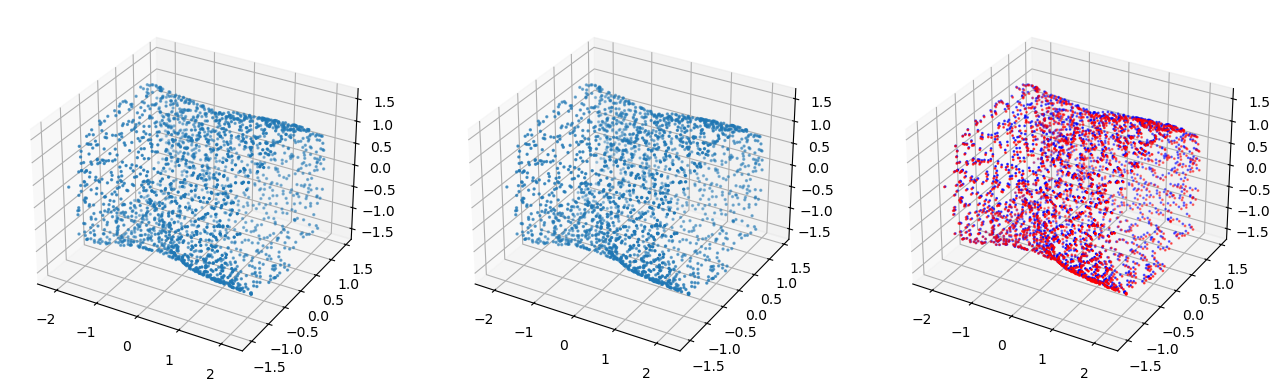

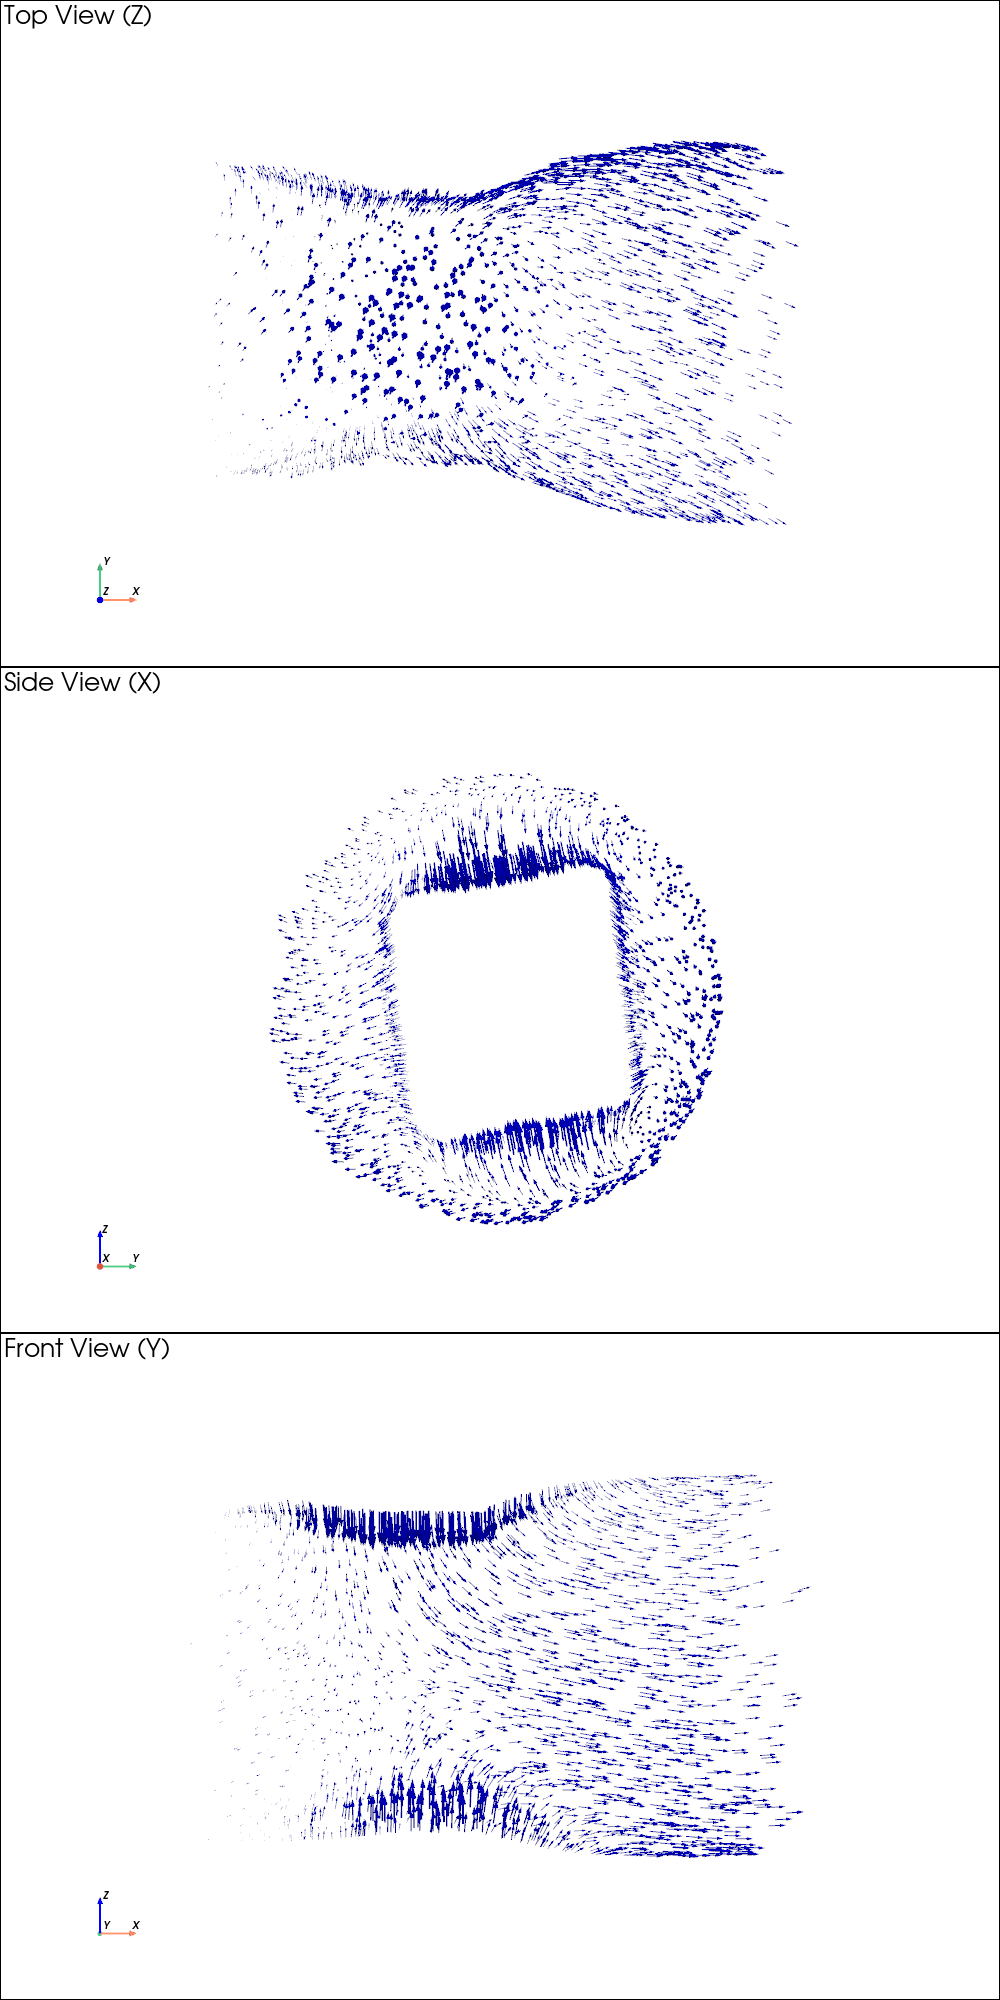

In [13]:
# visualize_point_cloud(c_t[25],a=-p[25], point_size=5)
idx = 30
print(s[idx])
compare_scatters(pc1=c_t[idx], pc2=c_tp1[idx])
visualize_vector_diff(c_t[idx],c_tp1[idx])


In [6]:
# np.savez('./test_comb_FOR.npz', coords_t=c_t, coords_tp1=c_tp1, steps=s, series_lengths=np.array(series_lengths))

In [7]:
np.savez('./test_comb_FOR_large_512.npz', coords_t=c_t, coords_tp1=c_tp1, steps=s, positions=p, rotations=r, series_lengths=np.array(series_lengths))